# Final evaluation: missing-data handling and API performance

## 1. Objective

The API now fills missing house attributes with the KNN imputation selected by the Data Science team
(`notebooks/imputation_experiment.ipynb`). Complete requests are already proven to give exactly the original
API's predictions (`test/fixtures/baseline_predictions.json`). This notebook answers the remaining questions:

1. How well does the production imputer reconstruct masked house attributes?
2. How much does imputation degrade house-price prediction quality on held-out data, compared with complete
   inputs and with simple mean imputation?
3. How did API latency and throughput change? (Measured earlier, reported here.)

This notebook is evidence, not application code. It reuses the production `fit_imputer` and the unchanged
model. Nothing is retrained.

**How to run.** From the repository root:
```bash
docker run --rm -v "$PWD:/work" -w /work/notebooks python:3.10-slim sh -c \
  "pip install -q -r ../requirements.txt -r requirements-notebook.txt && \
   jupyter nbconvert --to notebook --execute --inplace final_evaluation.ipynb"
```

## 2. Evaluation design

| Scenario | House features given to the model | Imputer |
|---|---|---|
| **Complete** | true values | none: the model's reference performance |
| **KNN-imputed** | masked cells filled by the **production** imputer | `KNNImputer(n_neighbors=5, weights="distance")` on 7 house features, fitted on the model's training split |
| **Mean-imputed** | the **same** masked cells filled with training-split means | `SimpleImputer(strategy="mean")`, used for evaluation only (not in the API) |

- **Prediction quality:** MAE, RMSE and R² of the **unchanged model** against the true `price` of the held-out rows.
- **Reconstruction quality:** per-feature MAE and RMSE of the imputed values on the masked cells.

These are error metrics, not "accuracy".

In [ ]:
import hashlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ---- Configuration 
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "model" / "model.pkl").is_file())
DATA_DIR, MODEL_DIR = REPO_ROOT / "src" / "data", REPO_ROOT / "src" / "model"
SPLIT_SEED = 42           # train_test_split seed used by create_model.py
MASK_RATE = 0.15          # MCAR rate per house feature, as in imputation_experiment.ipynb
MASK_SEED = 42            # RandomState seed of the main mask
ROBUSTNESS_SEEDS = range(5)
ROW_CHECK_SAMPLE = 300    # rows used to compare one-row (API) vs batch imputation
# The 7 house features the API accepts. The KNN configuration itself is NOT repeated here:
# it comes from production code (utils.loader.fit_imputer) and is checked in section 3.
HOUSE = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "sqft_above", "sqft_basement"]

sys.path.insert(0, str(REPO_ROOT / "src"))
from utils.loader import fit_imputer, load_features, load_model  # production code

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

ARTIFACT_HASHES = {name: sha256(MODEL_DIR / name) for name in ("model.pkl", "model_features.json")}

model = load_model(MODEL_DIR / "model.pkl")
model_features = load_features(MODEL_DIR / "model_features.json")
assert HOUSE == model_features[:7], "HOUSE must be the model's 7 house features"

# Same data preparation and split as create_model.py
sales = pd.read_csv(DATA_DIR / "kc_house_data.csv", usecols=["price"] + HOUSE + ["zipcode"], dtype={"zipcode": str})
demographics = pd.read_csv(DATA_DIR / "zipcode_demographics.csv", dtype={"zipcode": str})
data = sales.merge(demographics, how="left", on="zipcode").drop(columns="zipcode")
y = data.pop("price")
x_train, x_test, y_train, y_test = train_test_split(data, y, random_state=SPLIT_SEED)
assert (len(x_train), len(x_test)) == (16_209, 5_404), "unexpected split sizes"
print(f"train rows: {len(x_train)}, held-out rows: {len(x_test)}")

train rows: 16209, held-out rows: 5404


/Users/renan.oliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/renan.oliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/renan.oliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle e

## 3. Data split and leakage prevention

- The split is the one `create_model.py` used: `train_test_split(random_state=42)`. The check below confirms that
  the scaled training rows are exactly the rows stored inside the fitted KNN model.
- **Both imputers are fitted on training rows only.** The 5,404 held-out rows are never used as reference
  neighbors or for the means.
- **The imputers only see the 7 house features.** No `price`, ids, dates, zipcode or demographics.
- **`price` is used only to score predictions.** Demographics are joined by zipcode, exactly as the model expects.

In [2]:
knn_imputer = fit_imputer(DATA_DIR / "kc_house_data.csv", HOUSE)       # exactly what the API uses
mean_imputer = SimpleImputer(strategy="mean").fit(x_train[HOUSE])      # evaluation baseline only

all_missing = pd.DataFrame([[np.nan] * len(HOUSE)], columns=HOUSE)
checks = {
    "model was fitted on these training rows": np.allclose(model[0].transform(x_train[model_features]), model[-1]._fit_X),
    "train and held-out rows are disjoint": x_train.index.intersection(x_test.index).empty,
    "KNN imputer features == 7 house features": list(knn_imputer.feature_names_in_) == HOUSE,
    "price and zipcode are not imputer features": not {"price", "zipcode"} & set(knn_imputer.feature_names_in_),
    "KNN config: n_neighbors=5, weights='distance'": (knn_imputer.n_neighbors, knn_imputer.weights) == (5, "distance"),
    "KNN reference = training rows (mean fallback)": np.allclose(knn_imputer.transform(all_missing)[0], x_train[HOUSE].mean()),
    "mean imputer statistics = training means": np.allclose(mean_imputer.statistics_, x_train[HOUSE].mean()),
}
assert all(checks.values()), {k: v for k, v in checks.items() if not v}
pd.Series(checks, name="passed").to_frame()

,passed
model was fitted on these training rows,True
train and held-out rows are disjoint,True
KNN imputer features == 7 house features,True
price and zipcode are not imputer features,True
"KNN config: n_neighbors=5, weights='distance'",True
KNN reference = training rows (mean fallback),True
mean imputer statistics = training means,True


## 4. Missingness simulation

The protocol follows `introduce_missing_values` in the Data Science notebook: **MCAR**, and for each feature
independently exactly `int(n × 15%)` rows are drawn without replacement (`RandomState(42)`, NumPy's legacy
generator, as the notebook's `np.random.seed(42)` uses).

**Differences from the notebook, and why:**
- Only the **7 house features the API accepts** are masked. The notebook masked 17 columns, but the API never
  receives the other 10, and zipcode is always required.
- Masking is applied to the **held-out rows only**, and the imputer is fitted on complete training rows. The
  notebook masked and imputed the full dataset with `fit_transform`, which mixes reference and evaluation rows.

In [3]:
def mask_mcar(frame, rate, seed):
    rs = np.random.RandomState(seed)
    mask = pd.DataFrame(False, index=frame.index, columns=frame.columns)
    for col in frame.columns:
        rows = rs.choice(len(frame), size=int(len(frame) * rate), replace=False)
        mask.iloc[rows, mask.columns.get_loc(col)] = True
    return mask

house_true = x_test[HOUSE].astype(float)
mask = mask_mcar(house_true, MASK_RATE, MASK_SEED)
house_masked = house_true.mask(mask)

per_feature = int(len(house_true) * MASK_RATE)
assert (mask.sum() == per_feature).all() and mask.values.sum() == per_feature * len(HOUSE)
assert house_masked.isna().equals(mask), "NaNs must be exactly the masked cells"

per_row = mask.sum(axis=1)
print(f"masked cells: {mask.values.sum()} of {mask.size} ({mask.values.mean():.2%}); per feature: {mask.sum().iloc[0]}")
print(f"rows with >=1 masked feature: {(per_row > 0).sum()} of {len(mask)} ({(per_row > 0).mean():.1%})")
per_row.value_counts().sort_index().rename_axis("masked features per row").rename("rows").to_frame().T

masked cells: 5670 of 37828 (14.99%); per feature: 810
rows with >=1 masked feature: 3687 of 5404 (68.2%)


masked features per row,0,1,2,3,4,5
rows,1717,2164,1140,316,57,10


## 5. Imputation quality

Each masked cell is filled by both imputers, and the errors are computed only on masked cells, in each feature's
own units.

**Raw MAE and RMSE cannot be compared or averaged across features**, because their units differ (bedrooms vs
square feet). For a cross-feature view, the plot divides MAE by the training standard deviation of that feature.
That makes the scale unitless, but it is still a descriptive normalization, not a common loss.

The API imputes **one row per request**, while this evaluation imputes all rows at once. The check below confirms
that KNNImputer handles each row independently, so the batch results apply to the API.

In [4]:
house_knn = pd.DataFrame(knn_imputer.transform(house_masked), index=house_true.index, columns=HOUSE)
house_mean = pd.DataFrame(mean_imputer.transform(house_masked), index=house_true.index, columns=HOUSE)

# Both methods filled the same masked cells and left every other cell untouched
unmasked = ~mask.to_numpy()
for imputed in (house_knn, house_mean):
    assert not imputed.isna().to_numpy().any()
    assert np.array_equal(imputed.to_numpy()[unmasked], house_true.to_numpy()[unmasked])

sample = np.flatnonzero(per_row.to_numpy() > 0)[:ROW_CHECK_SAMPLE]
one_by_one = np.vstack([knn_imputer.transform(house_masked.iloc[[i]]) for i in sample])
row_by_row_equal = np.array_equal(one_by_one, house_knn.iloc[sample].to_numpy())
assert row_by_row_equal
print("row-by-row (API path) == batch:", row_by_row_equal)

train_std = x_train[HOUSE].std()
rows = []
for feature in HOUSE:
    m = mask[feature].to_numpy()
    truth = house_true[feature].to_numpy()[m]
    for method, imputed in [("KNN", house_knn), ("Mean", house_mean)]:
        values = imputed[feature].to_numpy()[m]
        mae = mean_absolute_error(truth, values)
        rows.append({"feature": feature, "method": method, "MAE": mae,
                     "RMSE": np.sqrt(mean_squared_error(truth, values)), "MAE / train std": mae / train_std[feature]})
imputation = pd.DataFrame(rows)
imputation_table = imputation.pivot(index="feature", columns="method").loc[HOUSE]
imputation_table.round(3)

row-by-row (API path) == batch: True


MAE                  RMSE            MAE / train std  \
method               KNN       Mean        KNN       Mean             KNN   
feature                                                                     
bedrooms           0.579      0.723      0.818      0.895           0.620   
bathrooms          0.368      0.619      0.524      0.778           0.481   
sqft_living      170.456    706.304    412.085    920.089           0.188   
sqft_lot       17973.225  15292.601  76921.167  71059.373           0.463   
floors             0.199      0.490      0.334      0.537           0.367   
sqft_above       154.015    649.431    377.258    819.117           0.187   
sqft_basement    110.382    364.309    251.112    446.440           0.252   

                      
method          Mean  
feature               
bedrooms       0.775  
bathrooms      0.809  
sqft_living    0.779  
sqft_lot       0.394  
floors         0.902  
sqft_above     0.790  
sqft_basement  0.831

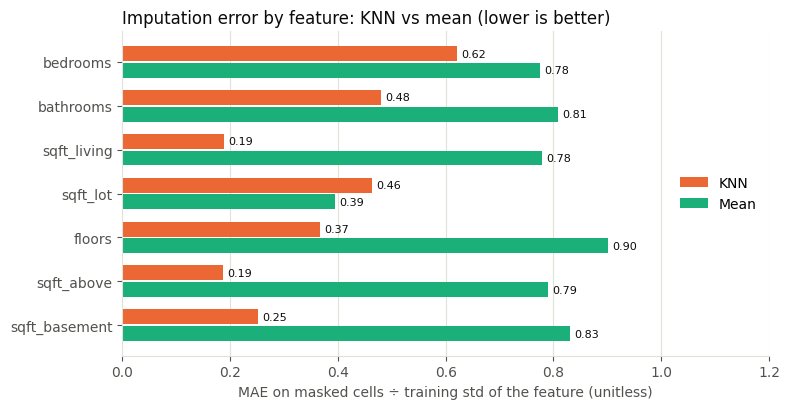

In [5]:
# Plot 1: does KNN reconstruct masked house attributes better than the mean?
COLORS = {"Complete": "#2a78d6", "KNN": "#eb6834", "Mean": "#1baf7a", "Original API": "#898781", "Final API": "#2a78d6"}
TEXT, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"

def style(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.tick_params(colors=MUTED)
    ax.set_axisbelow(True)

norm = imputation.pivot(index="feature", columns="method", values="MAE / train std").loc[HOUSE[::-1]]
fig, ax = plt.subplots(figsize=(8, 4.2))
pos, h = np.arange(len(norm)), 0.38
for offset, method in [(h / 2, "KNN"), (-h / 2, "Mean")]:
    bars = ax.barh(pos + offset, norm[method], height=h - 0.04, color=COLORS[method], label=method)
    ax.bar_label(bars, fmt="%.2f", padding=3, color=TEXT, fontsize=8)
ax.set_yticks(pos, norm.index)
ax.set_xlabel("MAE on masked cells ÷ training std of the feature (unitless)", color=MUTED)
ax.set_title("Imputation error by feature: KNN vs mean (lower is better)", loc="left", color=TEXT)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_xlim(0, 1.2)
ax.legend(frameon=False, loc="center right")
style(ax)
plt.tight_layout()
plt.show()

## 6. Downstream prediction impact

The **unchanged model** predicts `price` for all 5,404 held-out rows under each scenario. The second table
repeats the metrics for only the rows that had at least one masked feature, because unmasked rows give identical
predictions in every scenario and dilute the difference.

In [6]:
def scenario_inputs(house):
    frame = x_test.copy()
    frame[HOUSE] = house
    frame = frame[model_features]
    assert not frame.isna().to_numpy().any()
    return frame

predictions = {name: model.predict(scenario_inputs(house))
               for name, house in [("Complete", house_true), ("KNN", house_knn), ("Mean", house_mean)]}

def prediction_metrics(rows=slice(None)):
    return pd.DataFrame({
        name: {"MAE": mean_absolute_error(y_test.iloc[rows], p[rows]),
               "RMSE": np.sqrt(mean_squared_error(y_test.iloc[rows], p[rows])),
               "R²": r2_score(y_test.iloc[rows], p[rows])}
        for name, p in predictions.items()}).T

def formatted(metrics):
    out = metrics.copy()
    for col in ("MAE", "RMSE"):
        out[col] = out[col].map("{:,.0f}".format)
    out["R²"] = out["R²"].map("{:.4f}".format)
    return out.fillna("")

results = prediction_metrics()
for name in ("KNN", "Mean"):
    for metric in ("MAE", "RMSE"):
        diff = results.loc[name, metric] - results.loc["Complete", metric]
        results.loc[name, f"{metric} vs complete"] = f"{diff:+,.0f} ({diff / results.loc['Complete', metric]:+.1%})"
    results.loc[name, "R² vs complete"] = f"{results.loc[name, 'R²'] - results.loc['Complete', 'R²']:+.4f}"
print("All 5,404 held-out rows (price in USD)")
display(formatted(results))

knn_vs_mean = {m: results.loc["KNN", m] - results.loc["Mean", m] for m in ("MAE", "RMSE")}
print("KNN vs mean:", {m: f"{v:+,.0f} ({v / results.loc['Mean', m]:+.1%})" for m, v in knn_vs_mean.items()},
      f"R² {results.loc['KNN', 'R²'] - results.loc['Mean', 'R²']:+.4f}")

affected = per_row.to_numpy() > 0
print(f"\nOnly the {affected.sum()} rows with >=1 masked feature")
display(formatted(prediction_metrics(affected)))

All 5,404 held-out rows (price in USD)


,MAE,RMSE,R²,MAE vs complete,RMSE vs complete,R² vs complete
Complete,"102,068","201,680",0.7281,,,
KNN,"105,165","208,814",0.7085,"+3,097 (+3.0%)","+7,134 (+3.5%)",-0.0196
Mean,"109,849","212,495",0.6981,"+7,781 (+7.6%)","+10,815 (+5.4%)",-0.0299


KNN vs mean: {'MAE': '-4,685 (-4.3%)', 'RMSE': '-3,682 (-1.7%)'} R² +0.0104

Only the 3687 rows with >=1 masked feature


,MAE,RMSE,R²
Complete,"104,764","201,662",0.7340
KNN,"109,302","212,037",0.7059
Mean,"116,169","217,331",0.6911


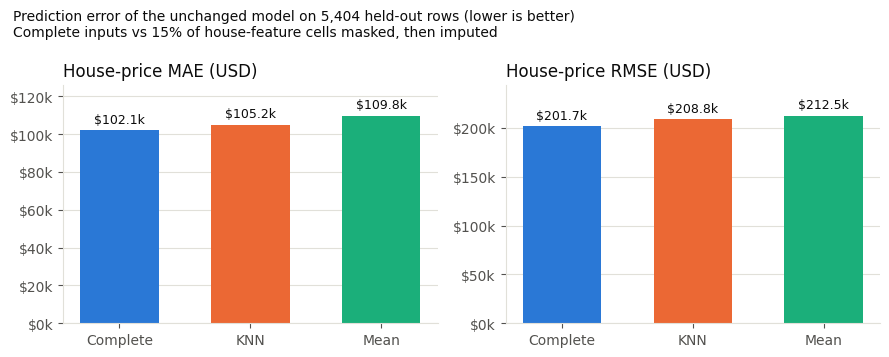

In [7]:
# Plot 2: how much does imputation cost in house-price prediction error?
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
names = ["Complete", "KNN", "Mean"]
for ax, metric in zip(axes, ["MAE", "RMSE"]):
    values = [results.loc[n, metric] for n in names]
    bars = ax.bar(names, values, width=0.6, color=[COLORS[n] for n in names])
    ax.bar_label(bars, labels=[f"${v / 1000:,.1f}k" for v in values], padding=3, color=TEXT, fontsize=9)
    ax.set_title(f"House-price {metric} (USD)", loc="left", color=TEXT)
    ax.set_ylim(0, max(values) * 1.15)
    ax.yaxis.set_major_formatter(lambda v, _: f"${v / 1000:.0f}k")
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    style(ax)
fig.suptitle("Prediction error of the unchanged model on 5,404 held-out rows (lower is better)\n"
             "Complete inputs vs 15% of house-feature cells masked, then imputed", x=0.02, ha="left", color=TEXT, fontsize=10)
plt.tight_layout()
plt.show()

**Robustness to the random mask.** A single seed could be lucky, so the same comparison is repeated with
5 other seeds (0–4), same protocol.

In [8]:
robust = []
for seed in ROBUSTNESS_SEEDS:
    m = mask_mcar(house_true, MASK_RATE, seed)
    masked = house_true.mask(m)
    row = {"seed": seed}
    for name, imputer in [("KNN", knn_imputer), ("Mean", mean_imputer)]:
        house = pd.DataFrame(imputer.transform(masked), index=house_true.index, columns=HOUSE)
        row[f"{name} MAE"] = mean_absolute_error(y_test, model.predict(scenario_inputs(house)))
    robust.append(row)
robust = pd.DataFrame(robust).set_index("seed")
robust["KNN − Mean"] = robust["KNN MAE"] - robust["Mean MAE"]
print(f"Complete-input MAE (no masking): {results.loc['Complete', 'MAE']:,.0f}")
robust.round(0).astype(int)

Complete-input MAE (no masking): 102,068


,KNN MAE,Mean MAE,KNN − Mean
seed,,,
0,104875,110603,-5728
1,105296,112225,-6928
2,104760,110989,-6229
3,105906,110636,-4731
4,106219,110581,-4362


## 7. API performance before vs after

These values were **measured earlier** (Prompt 7 benchmark, `benchmarks/benchmark.py`) and are not recomputed here:
- **Setup:** 3 interleaved rounds, each in a new container, on the same laptop (Docker Desktop, 14 CPUs).
- **Requests:** the 100 `future_unseen` rows; 300 sequential requests, then 500 requests from 1 client and from
  10 concurrent clients.
- **Images:** each was built from its own repository state. The original used its own Dockerfile, with
  `--reload` and unpinned dependencies.

Bars show the mean of the 3 rounds; the whiskers show the min–max across rounds. They cover complete requests only,
because the original API rejects incomplete requests (422) and so has no comparable latency.

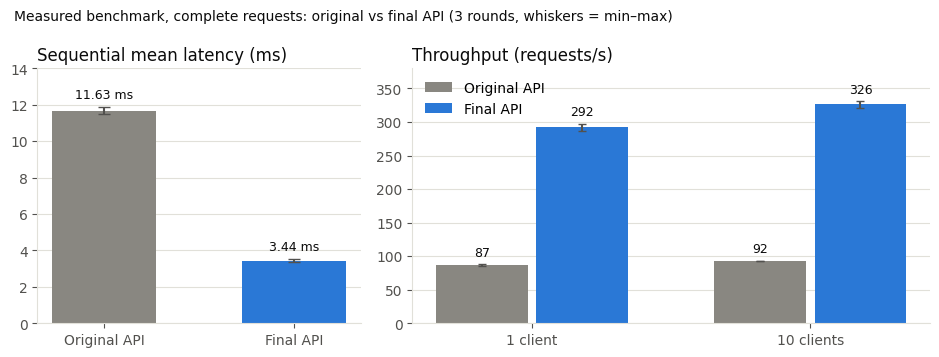

In [9]:
# Plot 3: did the refactor make the API faster? (measured benchmark results, complete requests)
latency = {"Original API": (11.63, 11.48, 11.89), "Final API": (3.44, 3.36, 3.54)}               # ms, mean (min, max)
throughput = {"1 client": {"Original API": (86.7, 85.10, 87.62), "Final API": (292.2, 286.67, 297.67)},
              "10 clients": {"Original API": (92.4, 92.17, 92.67), "Final API": (326.1, 321.29, 330.85)}}  # req/s

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.6), gridspec_kw={"width_ratios": [1, 1.6]})
for name, (mean, lo, hi) in latency.items():
    bar = ax1.bar(name, mean, width=0.55, color=COLORS[name], yerr=[[mean - lo], [hi - mean]], ecolor=MUTED, capsize=4)
    ax1.bar_label(bar, labels=[f"{mean:.2f} ms"], padding=4, color=TEXT, fontsize=9)
ax1.set_title("Sequential mean latency (ms)", loc="left", color=TEXT)
ax1.set_ylim(0, 14)

x, w = np.arange(len(throughput)), 0.36
for i, name in enumerate(["Original API", "Final API"]):
    vals = [throughput[k][name] for k in throughput]
    bars = ax2.bar(x + (i - 0.5) * w, [v[0] for v in vals], width=w - 0.03, color=COLORS[name], label=name,
                   yerr=[[v[0] - v[1] for v in vals], [v[2] - v[0] for v in vals]], ecolor=MUTED, capsize=3)
    ax2.bar_label(bars, labels=[f"{v[0]:.0f}" for v in vals], padding=4, color=TEXT, fontsize=9)
ax2.set_xticks(x, list(throughput))
ax2.set_title("Throughput (requests/s)", loc="left", color=TEXT)
ax2.set_ylim(0, 380)
ax2.legend(frameon=False, loc="upper left")
for ax in (ax1, ax2):
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    style(ax)
fig.suptitle("Measured benchmark, complete requests: original vs final API (3 rounds, whiskers = min–max)",
             x=0.02, ha="left", color=TEXT, fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
# Integrity: this notebook must not modify the model artifacts
assert {name: sha256(MODEL_DIR / name) for name in ARTIFACT_HASHES} == ARTIFACT_HASHES
print("model artifacts unchanged by this notebook")

model artifacts unchanged by this notebook


## 8. Conclusions and limitations

### Key findings (from the executed cells above)

- **Non-regression for complete inputs** is established separately: all 100 `future_unseen` predictions are
  identical to the original API (test suite). This notebook shows that the model's held-out error on complete
  inputs is the reference point for the scenarios below.
- **Prediction quality under 15% MCAR masking** (section 6): KNN imputation raises house-price MAE and RMSE above
  the complete-input reference by less than mean imputation does, and KNN has the lower MAE for every seed tested.
- **Reconstruction quality** (section 5): KNN reconstructs 6 of the 7 masked house features with lower MAE than the
  training mean. The exception is `sqft_lot`, where the mean is better. That matches the original notebook, where
  KNN was also worse than the mean for `sqft_lot`.
- **API performance** (section 7, measured earlier): sequential mean latency for complete requests fell from
  11.63 ms to 3.44 ms, and throughput rose about 3.4–3.5×.

### Limitations

- **Synthetic missingness:** the mask is MCAR. Real listings are more likely to miss values systematically
  (e.g. `sqft_basement` left blank when there is no basement), and this evaluation doesn't cover that.
- **One missingness level:** only 15% per feature (68% of rows affected). Other rates were not evaluated.
- **One dataset and split:** the held-out set is a single split of one historical dataset. `future_unseen_examples.csv`
  has no prices and can't be used for this evaluation.
- **Narrow comparison:** KNN is compared only with mean imputation. No other methods, and no scaling before KNN,
  which would change the Data Science team's method.
- **Normalized errors are descriptive:** MAE ÷ std puts features on one axis but is not a common loss.
  Reconstruction quality and prediction quality are different questions; a feature can be reconstructed poorly
  and still matter little to the model.